This project analyzes Amazon product data to explore how ratings, reviews, and other features relate to product purchases.

## Import libraries

We import all required libraries for data processing, visualization, and analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import seaborn as sns
import statsmodels.api as sm

## Load dataset

Load the dataset and preview the structure to understand available features.

In [2]:
data_url = "amazon_products.csv"
df=pd.read_csv(data_url)

In [3]:
df.head()

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00


## Initial data inspection

Check the data types to understand the dataset structure.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   

In [5]:
df['is_best_seller'].unique()

array(['No Badge', 'Best Seller', "Amazon's", 'Limited time deal',
       'Save 30%', 'Save 12%', 'Save 9%', 'Save 17%', 'Save 77%',
       'Ends in', 'Save 10%', 'Save 18%'], dtype=object)

In [6]:
df['product_category'].unique()

array(['Phones', 'Laptops', 'Other Electronics', 'Cameras', 'Storage',
       'Printers & Scanners', 'TV & Display', 'Power & Batteries',
       'Chargers & Cables', 'Headphones', 'Networking', 'Speakers',
       'Wearables', 'Gaming', 'Smart Home'], dtype=object)

In [7]:
df.columns
df = df.drop(columns = ['product_image_url', 'product_page_url', 'data_collected_at', 'delivery_date', 'sustainability_tags'])

## Check missing values

Define a function to summarize missing values across columns.

In [8]:
def missing_values(df):
    for i in df.columns:
        print(f"{i}: {df[i].isnull().sum()}, {df[i].isnull().sum() / len(df) * 100}")
missing_values(df)

product_title: 0, 0.0
product_rating: 1024, 2.3995313415348565
total_reviews: 1024, 2.3995313415348565
purchased_last_month: 10511, 24.630345635618042
discounted_price: 2062, 4.83186877562976
original_price: 2062, 4.83186877562976
is_best_seller: 0, 0.0
is_sponsored: 0, 0.0
has_coupon: 0, 0.0
buy_box_availability: 14653, 34.33626244874048
product_category: 0, 0.0
discount_percentage: 2062, 4.83186877562976


## Data cleaning

Deal with rows with missing values in key columns to ensure data quality.

In [9]:
df = df.dropna(subset = ['product_rating', 'purchased_last_month', 'discounted_price'])
df['buy_box_availability'] = df['buy_box_availability'].fillna(False)

missing_values(df)

product_title: 0, 0.0
product_rating: 0, 0.0
total_reviews: 0, 0.0
purchased_last_month: 0, 0.0
discounted_price: 0, 0.0
original_price: 0, 0.0
is_best_seller: 0, 0.0
is_sponsored: 0, 0.0
has_coupon: 0, 0.0
buy_box_availability: 0, 0.0
product_category: 0, 0.0
discount_percentage: 0, 0.0


## Feature engineering

Create new features such as coupon and badge indicators to capture their impact on purchases.

In [10]:
df['badge_group'] = (df['is_best_seller'] != 'No Badge').astype(int)
df['badge_group']

0        0
1        0
2        0
3        1
4        0
        ..
42670    0
42671    0
42672    1
42673    0
42674    0
Name: badge_group, Length: 30228, dtype: int64

In [11]:
df['has_coupon'] = df['has_coupon'].apply(lambda x: 'Coupon' if isinstance(x, str) and 'with coupon' in x.lower() else 'No Coupon')

df['is_best_seller'] = df['is_best_seller'].apply(lambda x: 'Best Seller' if isinstance(x, str) and 'best seller' in x.lower() else 'No Badge')

df = pd.get_dummies(df, columns=['is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability'], drop_first=True)

df.head()

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,product_category,discount_percentage,badge_group,is_best_seller_No Badge,is_sponsored_Sponsored,has_coupon_No Coupon,buy_box_availability_Add to cart
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,Phones,43.60,0,True,True,False,True
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,Laptops,37.52,0,True,True,True,True
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,Laptops,10.03,0,True,True,True,True
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Phones,0.00,1,False,False,True,False
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,Phones,0.00,0,True,False,True,False


In [12]:
df.columns

Index(['product_title', 'product_rating', 'total_reviews',
       'purchased_last_month', 'discounted_price', 'original_price',
       'product_category', 'discount_percentage', 'badge_group',
       'is_best_seller_No Badge', 'is_sponsored_Sponsored',
       'has_coupon_No Coupon', 'buy_box_availability_Add to cart'],
      dtype='object')

## Descriptive statistics

Summarize key variables to understand their distribution and central tendencies.

In [13]:
# Descriptive Statistics
main_vars = ["product_rating", "purchased_last_month"]
cols = main_vars

stats = pd.DataFrame({
    "count":  df[cols].count(),
    "mean":   df[cols].mean(numeric_only=True),
    "median": df[cols].median(numeric_only=True),
    "std":    df[cols].std(numeric_only=True, ddof=1),
    "min":    df[cols].min(numeric_only=True),
    "max":    df[cols].max(numeric_only=True),
    "nan_count":    df[cols].isna().sum(),
}).round(3)

In [14]:
stats

,count,mean,median,std,min,max,nan_count
product_rating,30228,4.439,4.5,0.359,2.0,5.0,0
purchased_last_month,30228,1354.570,200.0,6476.654,50.0,100000.0,0


**From the statistics of the two variables we can find interesting insights:**

1. We have more ratings than purchases. This is due to the fact that a lot of products were not bought last month but still have a rating from past purchases. We can see it from the number of nan_counts.

2. In stars the median is 4.5 and the mean is 4.399. The mean being lower is because of products with super low ratings. With purchased_last_month, the median is 200 and the mean is 1293.665. The mean is higher because there are products with a high numbers of purchases in the last month.

3. We also have products that have no rating.

## Data preparation

Select relevant columns and convert variables to numeric format for analysis.

In [15]:
# keep only needed cols, drop missing, ensure numeric
df_plot = df[['product_rating','purchased_last_month']].copy()
df_plot = df_plot.dropna()
df_plot['product_rating'] = pd.to_numeric(df_plot['product_rating'], errors='coerce')
df_plot['purchased_last_month'] = pd.to_numeric(df_plot['purchased_last_month'], errors='coerce')
df_plot = df_plot.dropna()

## Rating distribution

Visualize how product ratings are distributed.

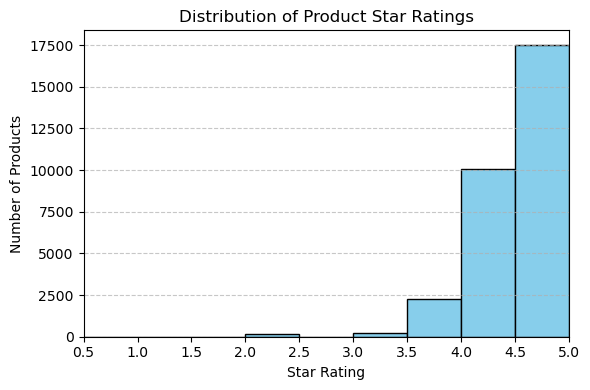

In [16]:
# Histogram: Distribution of Star Ratings
plt.figure(figsize=(6,4))

# Define bins up to 5.0 only
bins = np.arange(0.5, 5.1, 0.5)

plt.hist(df["product_rating"], bins=bins, color='skyblue', edgecolor='black')

plt.title('Distribution of Product Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Number of Products')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set ticks only up to 5.0
plt.xticks(np.arange(0.5, 5.1, 0.5))
plt.xlim(0.5, 5.0)

plt.tight_layout()
plt.show()

## Purchases distribution

Explore the distribution of monthly product purchases.

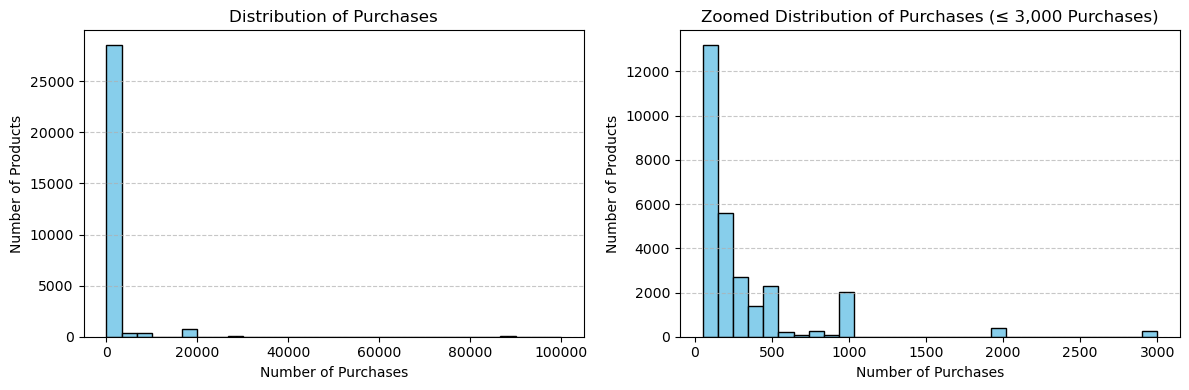

In [17]:
# Histogram: Distribution of Sales (Purchases Last Month）
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Full distribution
axes[0].hist(df_plot['purchased_last_month'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Purchases')
axes[0].set_xlabel('Number of Purchases')
axes[0].set_ylabel('Number of Products')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Right: Capped distribution (≤ 3000)
axes[1].hist(df_plot.loc[df_plot['purchased_last_month'] <= 3000, 'purchased_last_month'],
             bins=30, color='skyblue', edgecolor='black')
axes[1].set_title('Zoomed Distribution of Purchases (≤ 3,000 Purchases)')
axes[1].set_xlabel('Number of Purchases')
axes[1].set_ylabel('Number of Products')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Relationship between rating and purchases

Analyze how product ratings relate to sales performance.

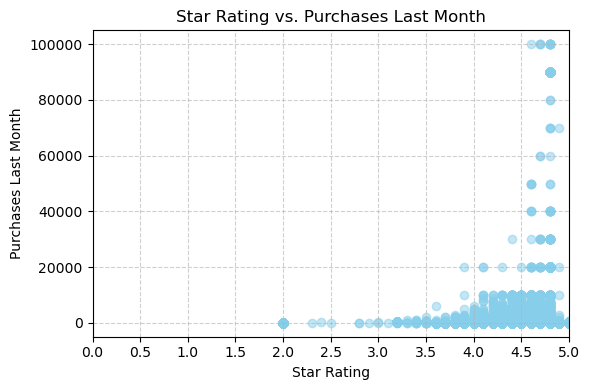

In [18]:
# Scatterplot: Star Rating vs. Sales
plt.figure(figsize=(6,4))
plt.scatter(df_plot['product_rating'], df_plot['purchased_last_month'], alpha=0.5, color='skyblue')
plt.title('Star Rating vs. Purchases Last Month')
plt.xlabel('Star Rating')
plt.ylabel('Purchases Last Month')
plt.grid(True, linestyle='--', alpha=0.6)

# Set x-axis from 0.0 to 5.0, with ticks every 0.5
plt.xlim(0, 5.0)
plt.xticks(np.arange(0, 5.1, 0.5))

plt.tight_layout()
plt.show()

## Grouping ratings

Group ratings into bins to simplify analysis and visualization.

In [19]:
# Group to nearest 0.5-star instead of integer
df_plot['rating_group'] = (df_plot['product_rating'] * 2).round() / 2
df_plot['rating_group'] = df_plot['rating_group'].clip(1, 5)

# Define the 0.5-step groups
groups = np.arange(1.0, 5.1, 0.5)  # 1.0, 1.5, ..., 5.0

# Build data + labels (skip empty groups to avoid empty boxes)
data = [df_plot.loc[df_plot['rating_group'] == g, 'purchased_last_month'] for g in groups]
labels = [str(g) for g, s in zip(groups, data) if not s.empty]
data   = [s for s in data if not s.empty]

## Boxplot analysis

Compare purchases across different rating groups to identify patterns.

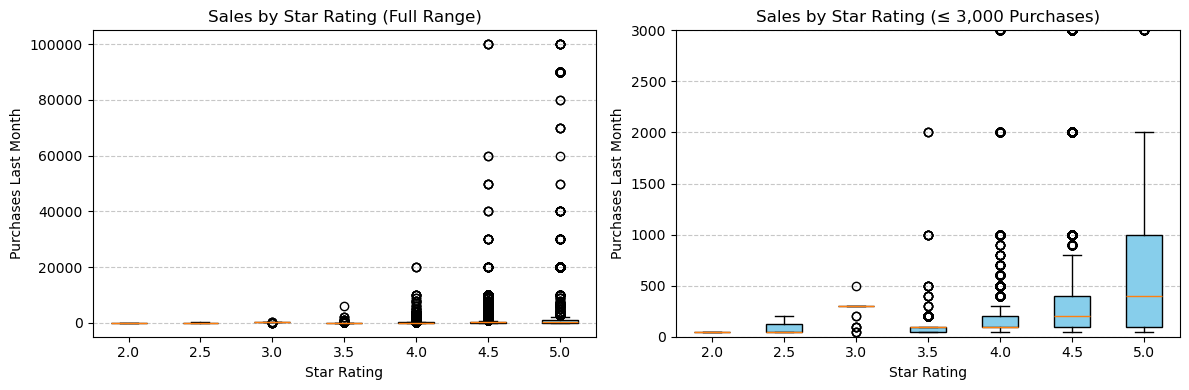

In [20]:
# Side-by-side boxplots
# Note: since we already know in our data, no orders have ratings below 2
# so that's why our boxplot's x-axis automatically starts from 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Full range
b1 = axes[0].boxplot(data, patch_artist=True)
for patch in b1['boxes']:
    patch.set(facecolor='skyblue', edgecolor='black')
axes[0].set_title('Sales by Star Rating (Full Range)')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Purchases Last Month')
axes[0].set_xticklabels(labels)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Right: Zoomed (≤ 3,000)
b2 = axes[1].boxplot(data, patch_artist=True)
for patch in b2['boxes']:
    patch.set(facecolor='skyblue', edgecolor='black')
axes[1].set_ylim(0, 3000)
axes[1].set_title('Sales by Star Rating (≤ 3,000 Purchases)')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Purchases Last Month')
axes[1].set_xticklabels(labels)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Insights for our x and y variables:**

- The distribution of rating is left-skewed. Majority of the ratings are between 4.0 inclusive and 5.0 exclusive. The mode is 4.5.

- The distribution of sales is right-skewed. Majority of the products have been bought less than 500 times in the past month.

- In the start rating vs purchases in the last month, we see that there is a weak positive correlation between both variables.

- In the box plots we can see that the number of outliers increases as the star rating increases. Same happens with the variability of the star rating.

## Correlation analysis

Examine relationships between numerical variables using correlation.

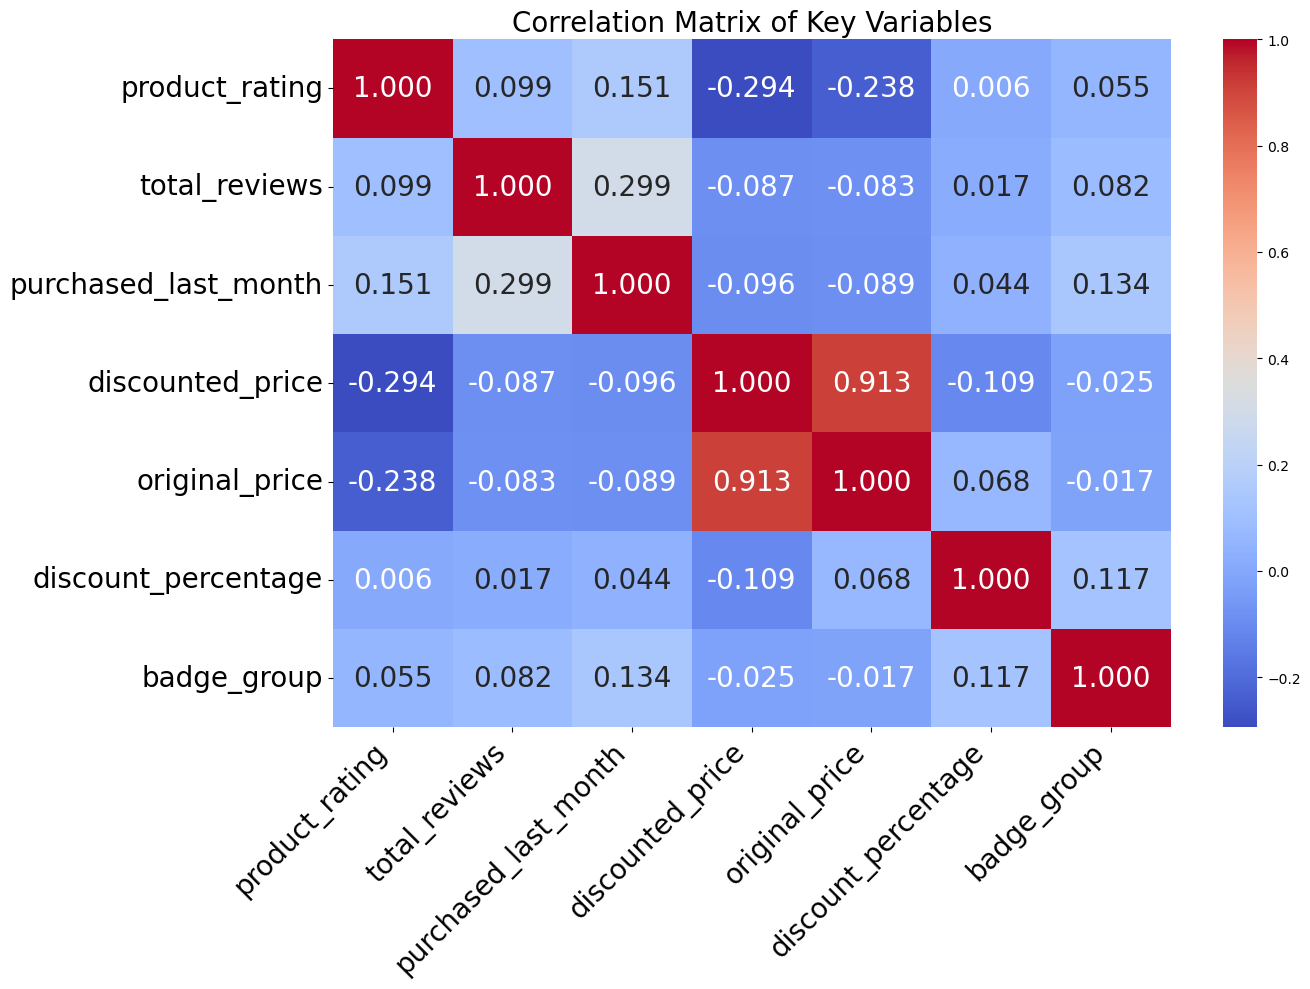

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage,badge_group
product_rating,1.000000,0.099372,0.151390,-0.294041,-0.238463,0.006486,0.055282
total_reviews,0.099372,1.000000,0.299240,-0.087026,-0.083030,0.016975,0.082394
purchased_last_month,0.151390,0.299240,1.000000,-0.095771,-0.089010,0.044170,0.134451
discounted_price,-0.294041,-0.087026,-0.095771,1.000000,0.913084,-0.108510,-0.025393
original_price,-0.238463,-0.083030,-0.089010,0.913084,1.000000,0.068095,-0.017453
discount_percentage,0.006486,0.016975,0.044170,-0.108510,0.068095,1.000000,0.117411
badge_group,0.055282,0.082394,0.134451,-0.025393,-0.017453,0.117411,1.000000


In [21]:
# Correlation Matrix & correlation coefficient r
corr_vars = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = corr_vars.corr(method='pearson')

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f",annot_kws={"size": 20})
plt.title("Correlation Matrix of Key Variables", fontsize=20)
plt.xticks(fontsize=20, rotation=45, ha='right')
plt.yticks(fontsize=20, rotation=0)
plt.tight_layout()
plt.show()

corr_matrix

## Confounding variables

Explore additional factors that may influence purchases beyond ratings.

In [22]:
# Confounding Variable Plots
df_conf = df.copy()

# Keep only purchases ≤ 3000 for clarity
df_conf = df_conf[df_conf['purchased_last_month'] <= 3000]

### Product category vs purchases

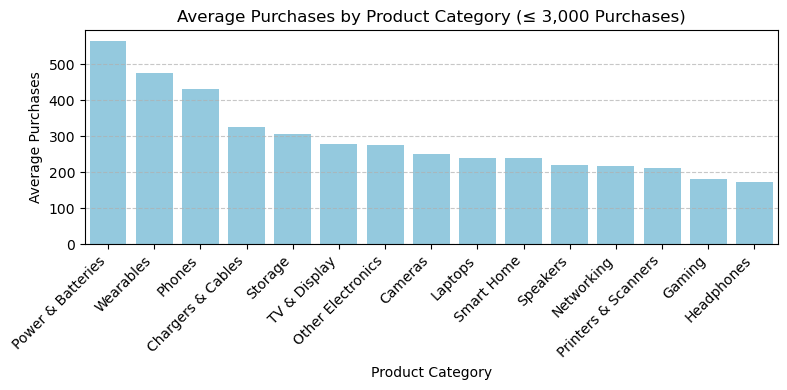

In [23]:
# Product Category vs Purchases
plt.figure(figsize=(8,4))

# Compute average purchases by category
avg_purchases = (
    df_conf.groupby('product_category')['purchased_last_month']
    .mean()
    .sort_values(ascending=False)
)

# Bar plot for average purchases
sns.barplot(
    x=avg_purchases.index,
    y=avg_purchases.values,
    color='skyblue'
)

plt.title('Average Purchases by Product Category (≤ 3,000 Purchases)')
plt.xlabel('Product Category')
plt.ylabel('Average Purchases')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Reviews vs purchases

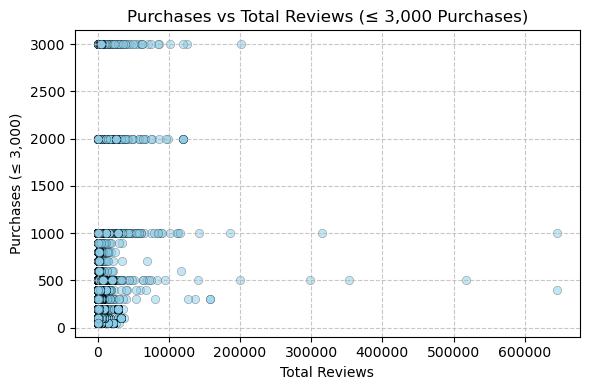

In [24]:
# Total Reviews vs Purchases
plt.figure(figsize=(6,4))

# Scatterplot showing relationship between reviews and purchases
sns.scatterplot(
    x='total_reviews',
    y='purchased_last_month',
    data=df_conf,
    color='skyblue',
    alpha=0.5,
    edgecolor='black',
    linewidth=0.3
)

plt.title('Purchases vs Total Reviews (≤ 3,000 Purchases)')
plt.xlabel('Total Reviews')
plt.ylabel('Purchases (≤ 3,000)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Badge effect on purchases

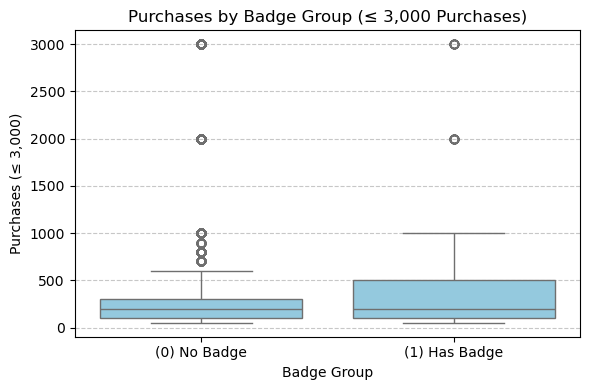

In [25]:
# Badge Group vs Purchases
plt.figure(figsize=(6, 4))

sns.boxplot(
    x='badge_group',
    y='purchased_last_month',
    data=df_conf,
    color='skyblue'
)

plt.title('Purchases by Badge Group (≤ 3,000 Purchases)')
plt.xlabel('Badge Group')
plt.ylabel('Purchases (≤ 3,000)')
plt.xticks([0, 1], ['(0) No Badge', '(1) Has Badge'])  # label 0/1 nicely
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Three confounding variables:**

1. Product Category – Different categories attract different levels of consumer demand; certain types (like electronics or toys) naturally sell more, making category a potential confounding factor affecting both rating and sales.

2. Total Reviews - Products with more reviews often appear more trustworthy or popular, which can increase sales while also correlating with higher ratings, creating overlap in influence.

3. Badge (No Badge, Best Seller, Amazon's Choice, Discount Badge) – Official badges like Best Seller signal product quality and popularity, directly boosting purchases and potentially influencing ratings, thus confounding the relationship between ratings and sales.

## Prepare data for modeling

Convert categorical variables into numerical format using dummy encoding.

Then, select numerical features and prepare the dataset for modeling by removing the target variable and adding a constant term.

Finally, we calculate the Variance Inflation Factor (VIF) to detect multicollinearity between variables. High VIF values indicate that some features are highly correlated and may affect model stability.

In [26]:
# convert category to numeric
df = pd.get_dummies(df, columns=['product_category'], drop_first=True)

In [27]:
# keep numeric features
X_num = df.select_dtypes(include=[float, int])
X_num = X_num.drop(columns=['product_rating'])
X_num = add_constant(X_num)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_num.columns
vif_data['VIF'] = [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]

print(vif_data)

                Feature       VIF
0                 const  1.983264
1         total_reviews  1.104747
2  purchased_last_month  1.119597
3      discounted_price  7.310382
4        original_price  7.258401
5   discount_percentage  1.237907
6           badge_group  1.034763


In [28]:
df.columns

Index(['product_title', 'product_rating', 'total_reviews',
       'purchased_last_month', 'discounted_price', 'original_price',
       'discount_percentage', 'badge_group', 'is_best_seller_No Badge',
       'is_sponsored_Sponsored', 'has_coupon_No Coupon',
       'buy_box_availability_Add to cart',
       'product_category_Chargers & Cables', 'product_category_Gaming',
       'product_category_Headphones', 'product_category_Laptops',
       'product_category_Networking', 'product_category_Other Electronics',
       'product_category_Phones', 'product_category_Power & Batteries',
       'product_category_Printers & Scanners', 'product_category_Smart Home',
       'product_category_Speakers', 'product_category_Storage',
       'product_category_TV & Display', 'product_category_Wearables'],
      dtype='object')

## Simple linear regression (rating vs purchases)

We start with a simple linear regression model using only product rating to predict monthly purchases.

This helps us understand the direct relationship between rating and sales before adding more variables.

                             OLS Regression Results                             
Dep. Variable:     purchased_last_month   R-squared:                       0.023
Model:                              OLS   Adj. R-squared:                  0.023
Method:                   Least Squares   F-statistic:                     709.0
Date:                  Mon, 23 Mar 2026   Prob (F-statistic):          2.00e-154
Time:                          02:46:49   Log-Likelihood:            -3.0782e+05
No. Observations:                 30228   AIC:                         6.156e+05
Df Residuals:                     30226   BIC:                         6.157e+05
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -1.077e+0

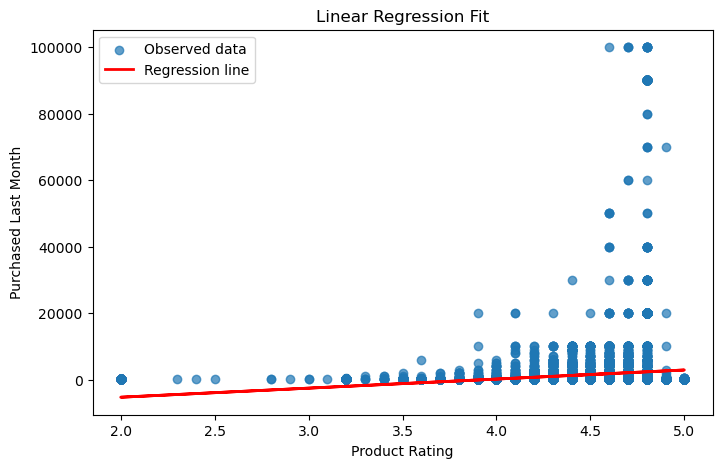

In [29]:
iX = df[['product_rating']]

y = df['purchased_last_month']

for col in iX.select_dtypes(include='bool').columns:
    iX[col] = iX[col].astype(int)

X = sm.add_constant(iX)

model = sm.OLS(y, X).fit()

print(model.summary())

rmse = np.sqrt(((model.resid) ** 2).mean())
print(f"RMSE: {rmse:.4f}")

plt.figure(figsize=(8,5))
plt.scatter(iX['product_rating'], y, alpha=0.7, label="Observed data")
plt.plot(iX['product_rating'], model.fittedvalues, color='red', linewidth=2, label="Regression line")
plt.xlabel("Product Rating")
plt.ylabel("Purchased Last Month")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()


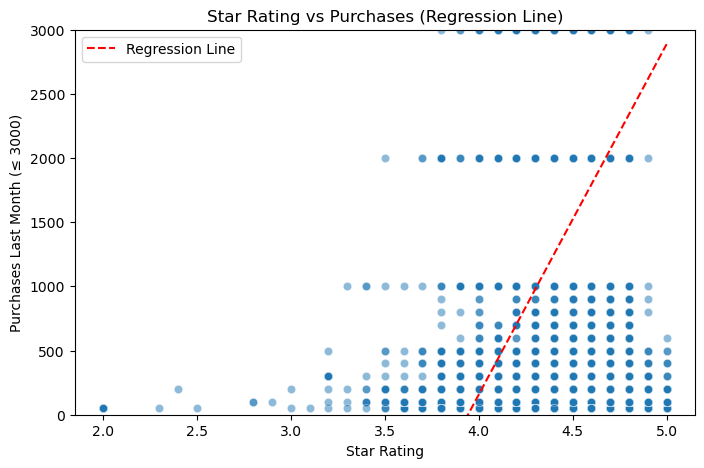

In [30]:
# Filter purchases <= 3000 for visualization
df_plot = df[df['purchased_last_month'] <= 3000]

# Prepare data for regression
X = sm.add_constant(df['product_rating'])
y = df['purchased_last_month']
model = sm.OLS(y, X).fit()

# Predictions for regression line
pred_x = np.linspace(df['product_rating'].min(), df['product_rating'].max(), 100)
pred_X = sm.add_constant(pred_x)
pred_y = model.predict(pred_X)

# Plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_plot,
    x='product_rating',
    y='purchased_last_month',
    alpha=0.5
)

# Regression line
plt.plot(pred_x, pred_y, color='red', linestyle='--', label='Regression Line')

# Limit y-axis to <= 3000 to zoom in and see the trend
plt.ylim(0, 3000)

plt.xlabel("Star Rating")
plt.ylabel("Purchases Last Month (≤ 3000)")
plt.title("Star Rating vs Purchases (Regression Line)")
plt.legend()
plt.show()


The regression results show that product rating has a positive and statistically significant relationship with purchases. Higher-rated products tend to have more monthly sales.

However, the R-squared value is very low, indicating that rating alone explains only a small portion of the variation in purchases. This suggests that other factors (such as reviews or product category) also play an important role.

## Multiple linear regression

We build a multiple regression model including rating, reviews, discounts, badges, sponsorship, coupons, and product categories.

This helps us understand how multiple factors jointly influence product purchases.

In [31]:
# Interaction features
df['int_pr_s'] = df['product_rating'] * df['is_sponsored_Sponsored']

                             OLS Regression Results                             
Dep. Variable:     purchased_last_month   R-squared:                       0.307
Model:                              OLS   Adj. R-squared:                  0.307
Method:                   Least Squares   F-statistic:                     638.5
Date:                  Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                          02:46:49   Log-Likelihood:            -3.0262e+05
No. Observations:                 30228   AIC:                         6.053e+05
Df Residuals:                     30206   BIC:                         6.055e+05
Df Model:                            21                                         
Covariance Type:              nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

/var/folders/2s/2f5vr80n5v3dkqq95t3s_fcm0000gn/T/ipykernel_44216/4164450823.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iX[col] = iX[col].astype(int)
/var/folders/2s/2f5vr80n5v3dkqq95t3s_fcm0000gn/T/ipykernel_44216/4164450823.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iX[col] = iX[col].astype(int)
/var/folders/2s/2f5vr80n5v3dkqq95t3s_fcm0000gn/T/ipykernel_44216/4164450823.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

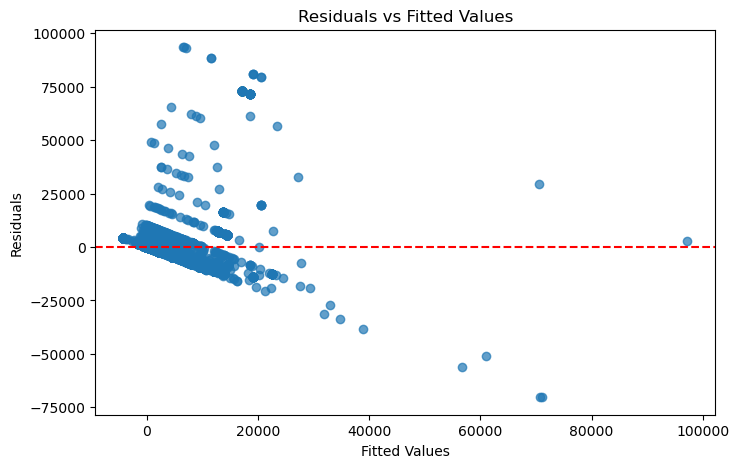

In [32]:
iX = df[['product_rating', 'discount_percentage', 'total_reviews', 'int_pr_s', 'badge_group', 'is_sponsored_Sponsored', 'has_coupon_No Coupon',
       'product_category_Chargers & Cables', 'product_category_Gaming',
       'product_category_Headphones', 'product_category_Laptops',
       'product_category_Networking', 'product_category_Other Electronics',
       'product_category_Phones', 'product_category_Power & Batteries',
       'product_category_Printers & Scanners', 'product_category_Smart Home',
       'product_category_Speakers', 'product_category_Storage',
       'product_category_TV & Display', 'product_category_Wearables']]

y = df['purchased_last_month']

for col in iX.select_dtypes(include='bool').columns:
    iX[col] = iX[col].astype(int)

X = sm.add_constant(iX)

model = sm.OLS(y, X).fit()

print(model.summary())

rmse = np.sqrt(((model.resid) ** 2).mean())
print(f"RMSE: {rmse:.4f}")

plt.figure(figsize=(8,5))
plt.scatter(model.fittedvalues, model.resid, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

The multiple regression model shows a significant improvement compared to the simple model (R² = 0.307), indicating that including additional variables helps better explain product purchases.

Several factors have strong and significant effects:
- **Total reviews** and **discount percentage** positively impact purchases, suggesting that social proof and promotions drive sales.
- **Sponsored products** and their interaction with rating (int_pr_s) have a large influence, indicating that visibility and marketing play a major role.
- **Product categories** also show varying effects, meaning demand differs across categories.

Interestingly, **product rating is no longer significant** when other variables are included. This suggests that rating alone is not a key driver of purchases once other factors are considered.